In [33]:
import pandas as pd
import numpy as np
import regex as re
import string
data = pd.read_csv(r"C:\Users\31760\Desktop\Inter DS\PBL2\intermediate-data-science-PBL2\reddit_dr.csv")
data.head()

,Title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,Text,Date Created
0,"No matter who someone is, how they look like, ...",Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,NaN,1.646272e+09
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,NaN,1.646271e+09
2,State of the union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,Who watched the state of the union last night ...,1.646270e+09
3,We Should Just Give Poor People Money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,NaN,1.646270e+09
4,Do it for the Dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,NaN,1.646268e+09


In [34]:

def clean_reddit_text(text):
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+", "", text)                 # remove mentions
    text = text.translate(str.maketrans("", "", string.punctuation))# remove punctuation
    text = re.sub(r"&[a-z]+;|&#x?\w+;", " ", text)
    text = re.sub(r"\[deleted\]|\[removed\]", " ", text)  
    text = re.sub(r"\s+", " ", text).strip()         # remove extra spaces
    return text

# Apply cleaning to the text
data["combined"] = (data["Title"].fillna("") + " " + data["Text"].fillna("")).apply(clean_reddit_text)
condition = data["Political Lean"].str.strip().str.lower() == "liberal"
data["isLiberal"] = np.where(condition, 1, 0)
x = data["combined"]
y = data["isLiberal"]

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0, stratify=y)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english")   # 
X_train_tfidf = vectorizer.fit_transform(X_train)    # 
X_test_tfidf  = vectorizer.transform(X_test)         # 

In [37]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train)
y_pred = logreg.predict(X_test_tfidf)
feature_names = vectorizer.get_feature_names_out()
coefs = logreg.coef_[0]
top_lib = np.argsort(coefs)[-15:]      # most Liberal
top_con = np.argsort(coefs)[:15]       # most Conservative
print("Liberal:", feature_names[top_lib])
print("Conservative:", feature_names[top_con])

Liberal: ['class' 'coup' 'statement' 'feminism' 'dsa' 'election' 'party' 'feminist'
 'opinion' 'plan' 'solidarity' 'democratic' 'cuba' 'workers' 'women']
Conservative: ['libertarian' 'desantis' 'libertarians' 'anarchocapitalism' 'capitalism'
 'trudeau' 'putin' 'ancap' 'property' 'ukraine' 'bitcoin' 'government'
 'durham' 'invasion' 'cpac']


In [38]:
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(accuracy_score(y_test, y_pred)))
print(classification_report(y_test, y_pred, target_names=["Conservative", "Liberal"]))

Accuracy of logistic regression classifier on test set: 0.76
              precision    recall  f1-score   support

Conservative       0.78      0.45      0.57      1361
     Liberal       0.76      0.93      0.84      2496

    accuracy                           0.76      3857
   macro avg       0.77      0.69      0.71      3857
weighted avg       0.77      0.76      0.74      3857



In [39]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_tfidf, y_train)             
y_pred = model.predict(X_test_tfidf)
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]
top_lib = np.argsort(coefs)[-15:]      # most Liberal
top_con = np.argsort(coefs)[:15]       # most Conservative
print("Liberal:", feature_names[top_lib])
print("Conservative:", feature_names[top_con])
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(accuracy_score(y_test, y_pred)))
print(classification_report(y_test, y_pred, target_names=["Conservative", "Liberal"]))

Liberal: ['coup' 'statement' 'class' 'feminism' 'dsa' 'election' 'feminist' 'plan'
 'opinion' 'party' 'solidarity' 'democratic' 'cuba' 'workers' 'women']
Conservative: ['libertarian' 'desantis' 'capitalism' 'putin' 'libertarians'
 'anarchocapitalism' 'trudeau' 'ukraine' 'government' 'property' 'ancap'
 'inflation' 'cpac' 'invasion' 'bitcoin']
Accuracy of logistic regression classifier on test set: 0.76
              precision    recall  f1-score   support

Conservative       0.66      0.68      0.67      1361
     Liberal       0.82      0.81      0.81      2496

    accuracy                           0.76      3857
   macro avg       0.74      0.74      0.74      3857
weighted avg       0.76      0.76      0.76      3857



In [40]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom = ['libertarian', 'anarchocapitalism', 'libertarians', 'ancap', 'cpac', 'dsa']
combined_stop = list(ENGLISH_STOP_WORDS.union(custom))

vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words=combined_stop, max_features=20000)
X_train_tfidf_f = vectorizer.fit_transform(X_train)    # 
X_test_tfidf_f  = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_tfidf_f, y_train)             
y_pred_f = model.predict(X_test_tfidf_f)
feature_names_f = vectorizer.get_feature_names_out()
coefs_f = model.coef_[0]
top_lib_f = np.argsort(coefs_f)[-15:]      # most Liberal
top_con_f = np.argsort(coefs_f)[:15]       # most Conservative
print("Liberal:", feature_names_f[top_lib_f])
print("Conservative:", feature_names_f[top_con_f])
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(accuracy_score(y_test, y_pred_f)))
print(classification_report(y_test, y_pred_f, target_names=["Conservative", "Liberal"]))


Liberal: ['democracy' 'coup' 'infrastructure' 'class' 'feminism' 'solidarity'
 'plan' 'democratic' 'opinion' 'election' 'party' 'feminist' 'cuba'
 'workers' 'women']
Conservative: ['desantis' 'putin' 'capitalism' 'ukraine' 'government' 'trudeau'
 'bitcoin' 'inflation' 'property' 'poll' 'russia' 'durham' 'canadian'
 'libertarianism' 'invasion']
Accuracy of logistic regression classifier on test set: 0.74
              precision    recall  f1-score   support

Conservative       0.63      0.66      0.64      1361
     Liberal       0.81      0.79      0.80      2496

    accuracy                           0.74      3857
   macro avg       0.72      0.72      0.72      3857
weighted avg       0.75      0.74      0.74      3857



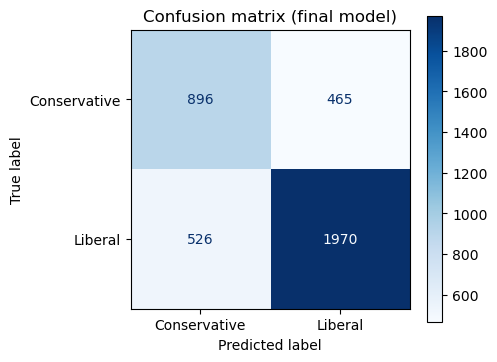

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_f,
    display_labels=["Conservative", "Liberal"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion matrix (final model)")
plt.tight_layout(); plt.savefig("fig2_confusion.png", dpi=150); plt.show()

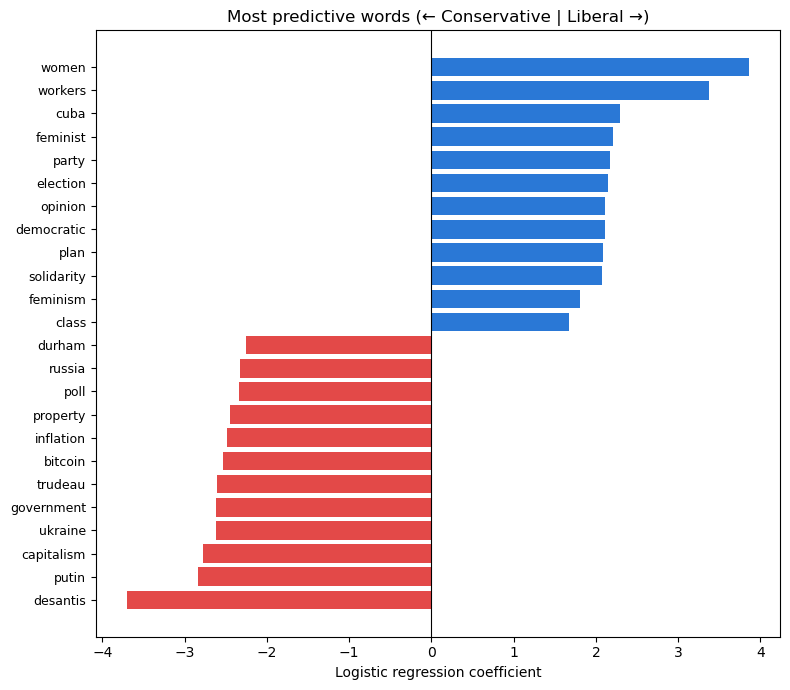

In [42]:
import numpy as np
import matplotlib.pyplot as plt

coefs_f = model.coef_[0]
names = vectorizer.get_feature_names_out()

n = 12
top_lib_idx = np.argsort(coefs_f)[-n:]
top_con_idx = np.argsort(coefs_f)[:n]
idx = np.concatenate([top_con_idx, top_lib_idx])
vals = coefs_f[idx]
labels = names[idx]
colors = ["#e34948" if v < 0 else "#2a78d6" for v in vals]   # 红=保守 蓝=自由

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(range(len(vals)), vals, color=colors)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Most predictive words (← Conservative | Liberal →)")
plt.tight_layout(); plt.savefig("fig3_coefs.png", dpi=150); plt.show()

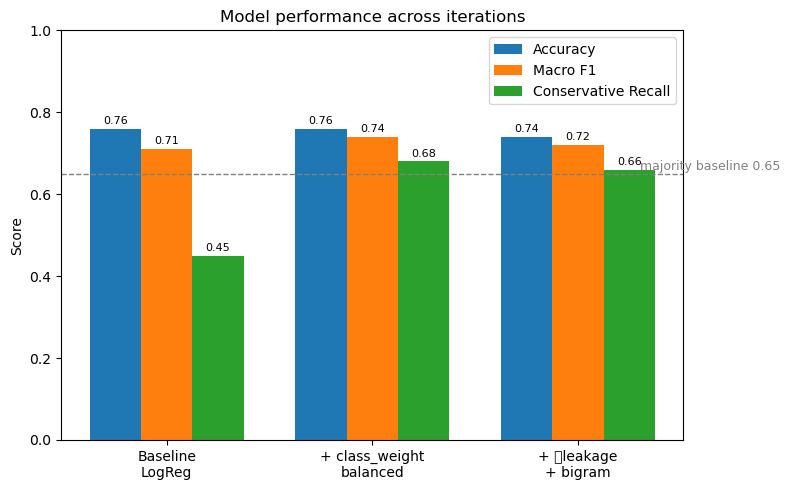

In [43]:
import matplotlib.pyplot as plt
import numpy as np

stages = ["Baseline\nLogReg", "+ class_weight\nbalanced", "+ 去leakage\n+ bigram"]
accuracy = [0.76, 0.76, 0.74]
macro_f1 = [0.71, 0.74, 0.72]
con_recall = [0.45, 0.68, 0.66]   

x = np.arange(len(stages))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, accuracy,   w, label="Accuracy")
ax.bar(x,     macro_f1,   w, label="Macro F1")
ax.bar(x + w, con_recall, w, label="Conservative Recall")

ax.set_xticks(x); ax.set_xticklabels(stages)
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.set_title("Model performance across iterations")
ax.legend()
ax.axhline(0.65, ls="--", color="gray", lw=1)  
ax.text(2.3, 0.66, "majority baseline 0.65", color="gray", fontsize=9)

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout(); plt.savefig("fig1_iterations.png", dpi=150); plt.show()

Random Forest   acc=0.735  macro-F1=0.713
XGBoost         acc=0.729  macro-F1=0.702

XGBoost report:
              precision    recall  f1-score   support

     Liberal       0.62      0.60      0.61      1361
Conservative       0.79      0.80      0.79      2496

    accuracy                           0.73      3857
   macro avg       0.70      0.70      0.70      3857
weighted avg       0.73      0.73      0.73      3857



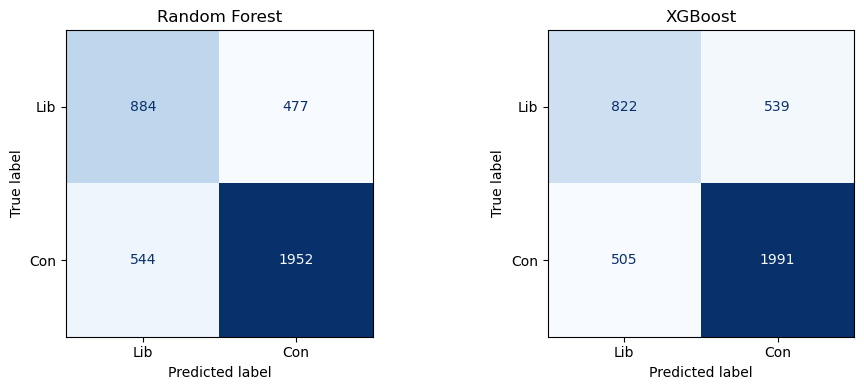

In [57]:
# --- 训练 + 评估 ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
spw = (y_train == 0).sum() / (y_train == 1).sum() 
rf = RandomForestClassifier(
    n_estimators=400, min_samples_leaf=2, class_weight="balanced",
    n_jobs=-1, random_state=42).fit(X_train_tfidf_f, y_train)

xgb = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
    eval_metric="logloss", n_jobs=-1, random_state=42).fit(X_train_tfidf_f, y_train)

for name, m in [("Random Forest", rf), ("XGBoost", xgb)]:
    p = m.predict(X_test_tfidf_f)
    print(f"{name:14s}  acc={accuracy_score(y_test, p):.3f}  "
          f"macro-F1={f1_score(y_test, p, average='macro'):.3f}")

print("\nXGBoost report:")
print(classification_report(y_test, xgb.predict(X_test_tfidf_f),
                            target_names=["Liberal", "Conservative"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, m) in zip(axes, [("Random Forest", rf), ("XGBoost", xgb)]):
    ConfusionMatrixDisplay.from_estimator(m, X_test_tfidf_f, y_test,
        display_labels=["Lib", "Con"], cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig("fig_tree_models.png", dpi=150); plt.show()

In [59]:
# --- 每个模型最看重的词 (可解释, 能放 slide) ---
import pandas as pd, numpy as np
vocab = np.array(vectorizer.get_feature_names_out())
for name, m in [("Random Forest", rf), ("XGBoost", xgb)]:
    top = pd.Series(m.feature_importances_, index=vocab).sort_values().tail(15)
    print(f"\n{name} top features:\n{top[::-1].round(4).to_string()}")


Random Forest top features:
women         0.0125
ukraine       0.0106
capitalism    0.0103
workers       0.0096
putin         0.0092
desantis      0.0090
russia        0.0088
trump         0.0068
biden         0.0063
government    0.0060
russian       0.0058
trudeau       0.0056
inflation     0.0055
poll          0.0046
bitcoin       0.0045

XGBoost top features:
women            0.0055
putin            0.0050
desantis         0.0049
workers          0.0046
working class    0.0043
property         0.0038
trudeau          0.0038
democracy        0.0038
inflation        0.0035
canadian         0.0035
democratic       0.0035
discuss          0.0035
durham           0.0035
bitcoin          0.0034
market           0.0034


## Topic Modeling (TF-IDF + NMF)

Beyond the supervised classifier, this section runs **unsupervised topic modeling** to discover the main themes in the posts and see how each theme splits between Liberal and Conservative.

- **Cleaning:** I reuse my teammate's EDA cleaning (lowercase, strip digits and reddit `r/`, `u/` handles) into a `topic_text` column — this removes more noise than the classifier's `combined` column, which keeps case and numbers.
- **Vectorizer:** TF-IDF with unigrams + bigrams.
- **Model:** NMF with 6 topics. NMF on a TF-IDF matrix gives cleaner, more interpretable topics than LDA on short social-media text.

In [44]:
# --- Text preparation for topic modeling ---
# Reuses my teammate's EDA cleaning style (lowercase, drop digits and reddit r//u/ handles),
# which is better suited to topic modeling than the classifier's `combined` column.
import re as _re

def clean_for_topics(text):
    text = str(text).lower()
    text = _re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = _re.sub(r"u/\w+|r/\w+", " ", text)       # remove reddit user / subreddit handles
    text = _re.sub(r"[^a-z\s]", " ", text)           # keep letters only (drops digits & punctuation)
    text = _re.sub(r"\s+", " ", text).strip()
    return text

data["topic_text"] = (
    data["Title"].fillna("") + " " + data["Text"].fillna("")
).apply(clean_for_topics)

data["topic_text"].head()

0    no matter who someone is how they look like wh...
1            biden speech draws million u s tv viewers
2    state of the union who watched the state of th...
3                we should just give poor people money
4                                    do it for the dew
Name: topic_text, dtype: str

In [45]:
# TF-IDF + NMF topic model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

N_TOPICS = 6

topic_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    max_features=10000,
)
X_topic = topic_vectorizer.fit_transform(data["topic_text"])

nmf = NMF(n_components=N_TOPICS, random_state=42, init="nndsvda", max_iter=500)
W = nmf.fit_transform(X_topic)   # document-topic weights
H = nmf.components_              # topic-term weights
terms = np.array(topic_vectorizer.get_feature_names_out())

print("TF-IDF matrix:", X_topic.shape)

TF-IDF matrix: (12854, 9679)


In [46]:
# Top words per topic
n_top = 12
for k in range(N_TOPICS):
    top_terms = terms[np.argsort(H[k])[-n_top:][::-1]]
    print(f"Topic {k}: " + ", ".join(top_terms))

Topic 0: people, like, just, don, think, government, right, know, want, women, workers, time
Topic 1: trump, donald trump, donald, says, election, gop, president, house, putin, cpac, jan, new
Topic 2: ukraine, russia, war, putin, russian, invasion, russia ukraine, nato, crisis, invasion ukraine, china, ukraine crisis
Topic 3: biden, joe, joe biden, president, court, putin, supreme court, supreme, president biden, poll, administration, biden administration
Topic 4: capitalism, anarcho, anarcho capitalism, socialism, market, capitalist, communism, crisis, free market, free, vs, economic
Topic 5: social, democracy, party, social democracy, democratic, socialism, democrats, socialist, communist, social democratic, social democrats, communist party


In [47]:
# Assign each post to its dominant topic and compare against the political lean
data["topic"] = W.argmax(axis=1)

print("Documents per topic:")
print(data["topic"].value_counts().sort_index(), "\n")

lean_by_topic = (
    pd.crosstab(data["topic"], data["Political Lean"], normalize="index")
    .mul(100)
    .round(1)
)
print("Political lean within each topic (%):")
lean_by_topic

Documents per topic:
topic
0    6977
1    1523
2    1213
3    1054
4     525
5    1562
Name: count, dtype: int64 

Political lean within each topic (%):


Political Lean,Conservative,Liberal
topic,,
0,32.1,67.9
1,38.0,62.0
2,53.9,46.1
3,43.7,56.3
4,60.0,40.0
5,18.6,81.4


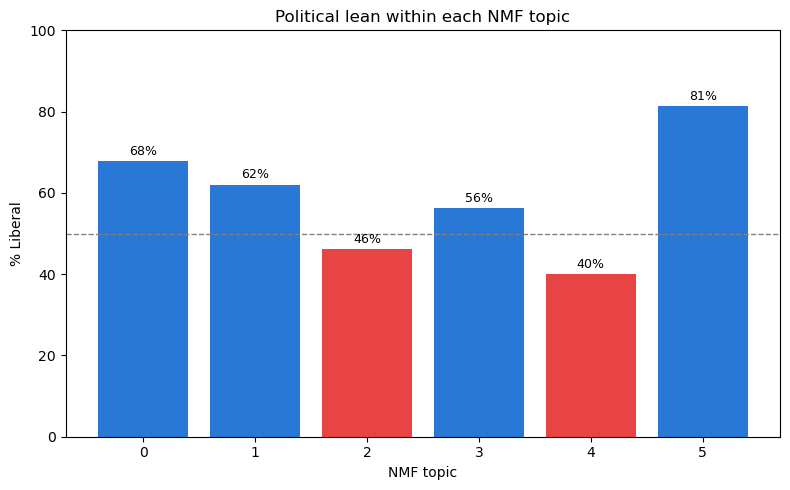

In [48]:
# Visualize the political lean of each topic
import matplotlib.pyplot as plt

lib_share = (
    pd.crosstab(data["topic"], data["Political Lean"], normalize="index")["Liberal"] * 100
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2a78d6" if v >= 50 else "#e94444" for v in lib_share]  # blue = leans Liberal, red = leans Conservative
ax.bar(lib_share.index.astype(str), lib_share.values, color=colors)
ax.axhline(50, ls="--", color="gray", lw=1)
ax.set_xlabel("NMF topic")
ax.set_ylabel("% Liberal")
ax.set_ylim(0, 100)
ax.set_title("Political lean within each NMF topic")
for i, v in enumerate(lib_share.values):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig4_topics.png", dpi=150)
plt.show()

### Interpreting the topics

Using `argmax` on the document–topic matrix, every post is assigned to its dominant topic, then cross-tabulated against `Political Lean`:

| Topic | Theme (top words) | Leans |
|-------|-------------------|-------|
| Society | general / people, government, rights, women, workers | Liberal (~68%) |
| Trump | Trump, election, GOP, CPAC | Liberal (~62%) |
| Ukraine | Russia–Ukraine war, Putin, NATO | **Conservative (~54%)** |
| Biden | Biden, Supreme Court, administration | Liberal (~56%) |
| Capitalism | capitalism / anarcho-capitalism, socialism, free market | **Conservative (~60%)** |
| Socialism | social democracy, socialism, communist party | Liberal (~81%) |

**Takeaway:** the topics line up with the logistic-regression coefficients from the classification section — economic-ideology debates (Topic 4) and the Ukraine war (Topic 2) skew conservative, while party/movement organizing (Topic 5) skews strongly liberal. Topic modeling is *unsupervised*, so this agreement is a useful sanity check that the political signal in the text is real and not just an artifact of the labels.


In [ ]:

KEEP = {
    0:  "Politicians (Trump/Biden/DeSantis)",
    1:  "Russia–Ukraine war",
    2:  "Capitalism vs Socialism (theory)",
    4:  "Supreme Court / law",
    7:  "Labor & policing",
    12: "Anti-Biden / 'Let's go Brandon'",
}
contrasts = ["care_minus_harm", "fairness_minus_cheating", "loyalty_minus_betrayal",
             "authority_minus_subversion", "purity_minus_degradation", "liberty_minus_oppression"]

topic_model.set_topic_labels(KEEP)                       
dff = df[df["topic"].isin(KEEP)].copy()
dff["topic_label"] = dff["topic"].map(KEEP)
print(f"聚焦 {len(KEEP)} 个 topic，{len(dff)}/{len(df)} 帖 "
      f"({len(dff)/len(df)*100:.0f}%)，其余归为 general discussion。")

聚焦 6 个 topic，6954/12854 帖 (54%)，其余归为 general discussion。


In [ ]:

base_lib = (df["Political Lean"] == "Liberal").mean()    
g = dff.groupby("topic_label")
summary = pd.DataFrame({"n": g.size(),
                        "pct_liberal": g["Political Lean"].apply(lambda s: (s=="Liberal").mean())})
summary["lift_vs_base"] = summary["pct_liberal"] - base_lib   
summary = summary.sort_values("lift_vs_base")
print(f"corpus base rate = {base_lib*100:.1f}% Liberal\n")
summary.round(3)

corpus base rate = 64.7% Liberal



,n,pct_liberal,lift_vs_base
topic_label,,,
Politicians (Trump/Biden/DeSantis),1718,0.515,-0.132
Russia–Ukraine war,1470,0.586,-0.061
Anti-Biden / 'Let's go Brandon',631,0.645,-0.002
Capitalism vs Socialism (theory),1192,0.669,0.021
Supreme Court / law,1099,0.707,0.060
Labor & policing,844,0.805,0.157


In [ ]:
mask = dff["date"] >= "2021-01-01"
docs_dff = dff["Text"].fillna("").astype(str).tolist()
tot = topic_model.topics_over_time(
    [d for d, m in zip(docs_dff, mask) if m],
    dff.loc[mask, "date"].tolist(),
    topics=dff.loc[mask, "topic"].tolist(), nr_bins=15)
fig = topic_model.visualize_topics_over_time(tot, custom_labels=True)
fig.write_html("topics_over_time.html"); fig.show()

15it [00:00, 23.80it/s]


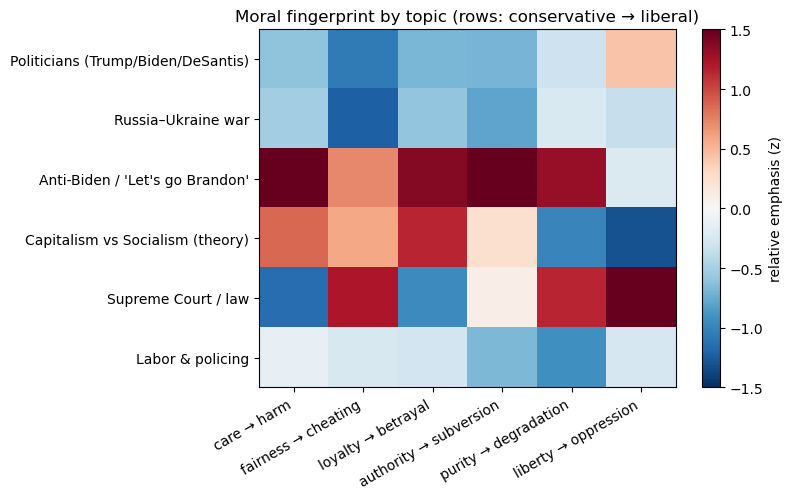

In [ ]:

order = summary.index.tolist()
tm = dff.groupby("topic_label")[contrasts].mean().loc[order]
z = (tm - tm.mean()) / tm.std()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 0.6*len(z) + 1.5))
im = ax.imshow(z.values, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
ax.set_xticks(range(len(contrasts)))
ax.set_xticklabels([c.replace("_minus_", " → ") for c in contrasts], rotation=30, ha="right")
ax.set_yticks(range(len(z))); ax.set_yticklabels(z.index)
fig.colorbar(im, label="relative emphasis (z)")
ax.set_title("Moral fingerprint by topic (rows: conservative → liberal)")
plt.tight_layout(); plt.savefig("fig_topic_moral.png", dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
from scipy.stats import mannwhitneyu
for d_ in (df, dff):
    d_["individualizing"] = d_[["care_minus_harm","fairness_minus_cheating"]].mean(axis=1)
    d_["binding"] = d_[["loyalty_minus_betrayal","authority_minus_subversion",
                        "purity_minus_degradation"]].mean(axis=1)

print("=== All posts: Conservative vs Liberal ===")
for axis in ["individualizing", "binding", "liberty_minus_oppression"]:
    con = df.loc[df["Political Lean"]=="Conservative", axis]
    lib = df.loc[df["Political Lean"]=="Liberal", axis]
    _, p = mannwhitneyu(con, lib, alternative="two-sided")
    print(f"{axis:24s} con={con.mean():+.3f} lib={lib.mean():+.3f} "
          f"diff={con.mean()-lib.mean():+.3f} p={p:.1e}")

=== All posts: Conservative vs Liberal ===
individualizing          con=-0.034 lib=-0.018 diff=-0.015 p=1.9e-40
binding                  con=-0.051 lib=-0.045 diff=-0.006 p=5.0e-10
liberty_minus_oppression con=-0.013 lib=-0.009 diff=-0.004 p=7.2e-07


In [ ]:

dff.groupby("topic_label")["Subreddit"].apply(
    lambda s: s.value_counts(normalize=True).iloc[0]).round(2).sort_values(ascending=False)


topic_label
Anti-Biden / 'Let's go Brandon'       0.24
Labor & policing                      0.21
Politicians (Trump/Biden/DeSantis)    0.19
Supreme Court / law                   0.17
Capitalism vs Socialism (theory)      0.15
Russia–Ukraine war                    0.15
Name: Subreddit, dtype: float64